# RANSAC for Robust Line Detection in Noisy Images

This notebook analyzes the effectiveness of **RANSAC (Random Sample Consensus)** in detecting lines and handling outliers in a noisy image. We create a synthetic image containing three known straight lines overlaid with **Gaussian noise** and **random outlier points**, then compare:

1. **Standard Least-Squares fitting** — a non-robust method that is highly sensitive to outliers.
2. **RANSAC line fitting** — a robust iterative method that identifies inliers and outliers, then fits lines using only the inlier set.

The outlier ratio is over 60%, making this a challenging scenario that highlights RANSAC's robustness.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Create a Synthetic Noisy Image

We generate an image with **three horizontal lines** at known positions (y = 50, y = 150, y = 280). Gaussian noise is added to the line points, and a large number of **random outlier points** are scattered across the image. This creates a point cloud where over 60% of points are outliers — a scenario where standard least-squares fitting fails catastrophically.

In [2]:
np.random.seed(42)
W, H = 400, 400

true_line_ys = [50, 150, 280]

inlier_points = []
for y in true_line_ys:
    for x in range(40, 380, 4):
        inlier_points.append([x, y])

inlier_points = np.array(inlier_points, dtype=np.float32)
inlier_points[:, 1] += np.random.normal(0, 6, len(inlier_points))

n_outliers = 400
outlier_points = np.column_stack([
    np.random.randint(10, W - 10, n_outliers),
    np.random.randint(10, H - 10, n_outliers)
]).astype(np.float32)

all_points = np.vstack([inlier_points, outlier_points])

outlier_ratio = n_outliers / len(all_points)
print(f'Total points: {len(all_points)}')
print(f'Inlier points (on true lines): {len(inlier_points)}')
print(f'Outlier points (random): {n_outliers}')
print(f'Outlier ratio: {outlier_ratio:.1%}')

Total points: 655
Inlier points (on true lines): 255
Outlier points (random): 400
Outlier ratio: 61.1%


## Visualize the Noisy Point Cloud

The image below shows all points (inliers + outliers) overlaid on a light-gray background. The three true lines are indicated with blue reference lines. The outliers are densely scattered, making the true lines difficult to discern visually.

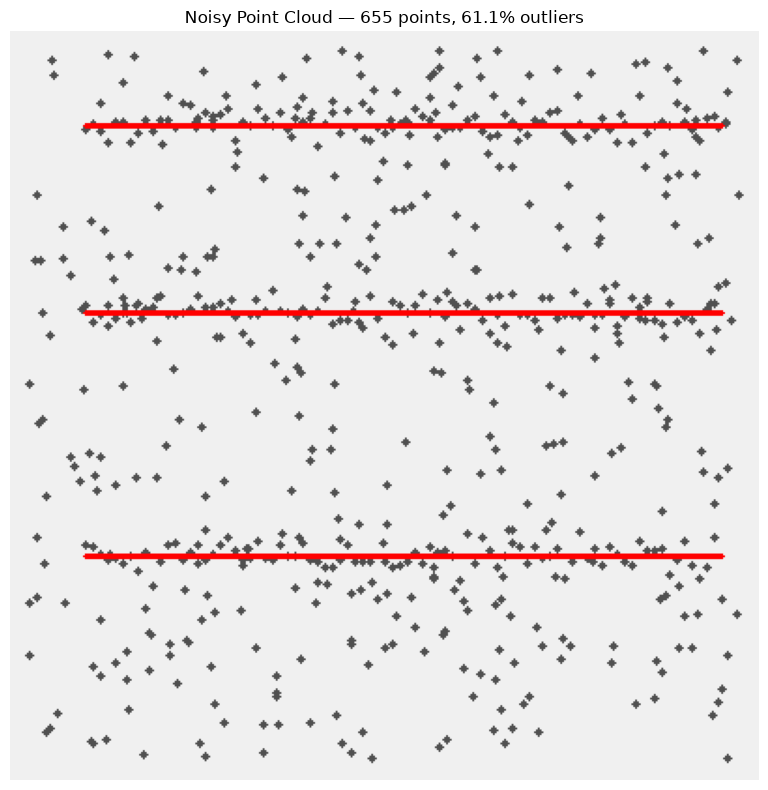

In [3]:
vis = np.zeros((H, W, 3), dtype=np.uint8)
vis[:] = 240

for pt in all_points:
    cv2.circle(vis, (int(pt[0]), int(pt[1])), 2, (80, 80, 80), -1)

for y in true_line_ys:
    cv2.line(vis, (40, int(y)), (380, int(y)), (255, 0, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(vis)
plt.title(f'Noisy Point Cloud — {len(all_points)} points, {outlier_ratio:.1%} outliers')
plt.axis('off')
plt.show()

## 1. Standard Least-Squares Line Fitting (Non-Robust)

The **least-squares** method fits a line by minimizing the sum of squared distances from all points to the line. This is a **non-robust** method — every point, including outliers, contributes equally to the fit. With 60%+ outliers, the fitted line is pulled toward the outlier cloud and no longer represents any true line.

The least-squares line is computed using the **covariance matrix** of the point cloud. The principal axis (eigenvector with smallest eigenvalue) gives the line direction, and the centroid gives a point on the line.

Least-Squares line: a=-0.495, b=0.869, c=-57.829
Mean distance to LS line: 93.0 pixels
Median distance to LS line: 86.3 pixels


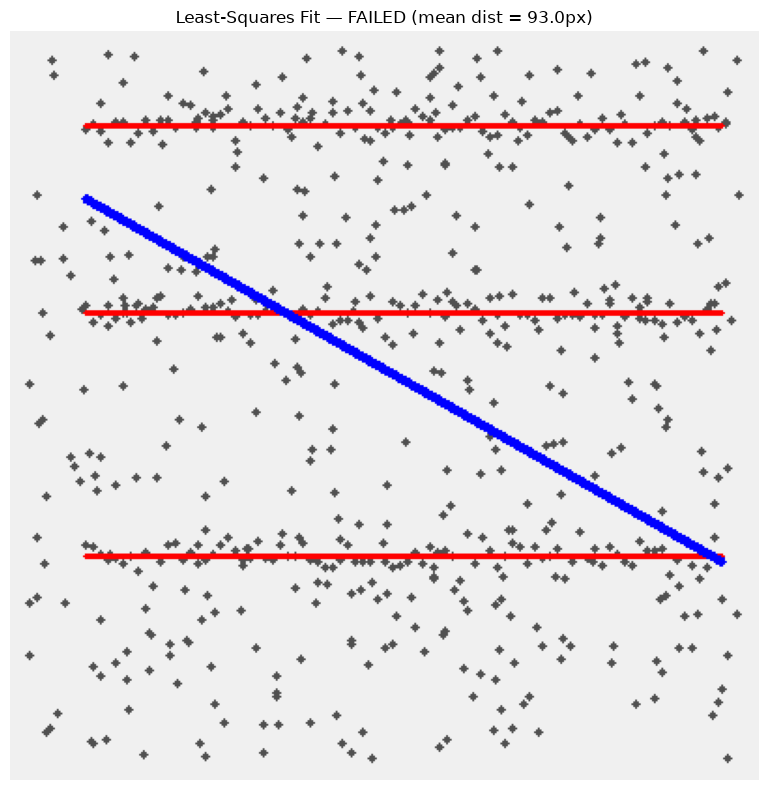

In [4]:
def fit_line_least_squares(points):
    mean = np.mean(points, axis=0)
    centered = points - mean
    cov = centered.T @ centered
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    idx = np.argmin(eigenvalues)
    direction = eigenvectors[:, idx]
    a, b = direction[1], -direction[0]
    c = -(a * mean[0] + b * mean[1])
    return a, b, c, mean

ls_a, ls_b, ls_c, ls_mean = fit_line_least_squares(all_points)

ls_display = vis.copy()
x_vals = np.array([40, 380])
if abs(ls_b) > 1e-6:
    y_vals = -(ls_a * x_vals + ls_c) / ls_b
    cv2.line(ls_display, (int(x_vals[0]), int(y_vals[0])), (int(x_vals[1]), int(y_vals[1])), (0, 0, 255), 3)

ls_err = np.abs(ls_a * all_points[:, 0] + ls_b * all_points[:, 1] + ls_c) / np.sqrt(ls_a**2 + ls_b**2)
print(f'Least-Squares line: a={ls_a:.3f}, b={ls_b:.3f}, c={ls_c:.3f}')
print(f'Mean distance to LS line: {np.mean(ls_err):.1f} pixels')
print(f'Median distance to LS line: {np.median(ls_err):.1f} pixels')

plt.figure(figsize=(10, 8))
plt.imshow(ls_display)
plt.title(f'Least-Squares Fit — FAILED (mean dist = {np.mean(ls_err):.1f}px)')
plt.axis('off')
plt.show()

## 2. RANSAC — Random Sample Consensus

RANSAC is an **iterative, robust** algorithm that fits a model (here, a line) even when a large fraction of the data consists of outliers. Unlike least-squares, RANSAC does not use all points — instead, it repeatedly samples a minimal subset of points, fits a model to the subset, and counts how many other points agree (inliers).

### RANSAC Algorithm (per line):

1. **Randomly sample** 2 points (the minimum needed to define a line).
2. **Fit a line** through the sampled points using the line equation `ax + by + c = 0`.
3. **Compute distances** from all remaining points to the line.
4. **Count inliers** — points whose distance is below a threshold.
5. **Repeat** steps 1–4 for N iterations.
6. **Select** the line with the maximum number of inliers.

### Multi-Line Detection:

To detect **multiple lines**, RANSAC is run iteratively:
1. Find the best line using RANSAC.
2. **Remove all inliers** belonging to that line from the point set.
3. Repeat on the remaining points until too few points remain.

This approach ensures each line is detected independently, even when lines are interleaved with outlier noise.

In [5]:
def ransac_line(points, n_iterations=500, threshold=10.0):
    best_inliers = []
    best_model = None
    for _ in range(n_iterations):
        idx = np.random.choice(len(points), 2, replace=False)
        p1, p2 = points[idx[0]], points[idx[1]]
        dx, dy = p2 - p1
        norm = np.sqrt(dx**2 + dy**2)
        if norm < 1e-6:
            continue
        a, b = dy, -dx
        c = -(a * p1[0] + b * p1[1])
        dists = np.abs(a * points[:, 0] + b * points[:, 1] + c) / np.sqrt(a**2 + b**2)
        inliers = np.where(dists < threshold)[0]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (a, b, c)
    return best_model, best_inliers

remaining_points = all_points.copy()

detected_lines = []

for i in range(len(true_line_ys)):
    model, inliers = ransac_line(remaining_points, n_iterations=500, threshold=10.0)
    if model is None or len(inliers) < 5:
        break
    detected_lines.append((model, inliers))
    mask = np.ones(len(remaining_points), dtype=bool)
    mask[inliers] = False
    remaining_points = remaining_points[mask]

print(f'RANSAC detected {len(detected_lines)} lines:')
for i, (model, inliers) in enumerate(detected_lines):
    a, b, c = model
    print(f'  Line {i+1}: a={a:.3f}, b={b:.3f}, c={c:.3f} — {len(inliers)} inliers')

RANSAC detected 3 lines:
  Line 1: a=1.112, b=-100.000, c=14847.377 — 105 inliers
  Line 2: a=-0.253, b=-194.000, c=9989.702 — 100 inliers
  Line 3: a=-4.341, b=215.000, c=-59495.016 — 89 inliers


## RANSAC Results — Inlier/Outlier Visualization

The figure below shows the RANSAC results. Points are color-coded:
- **Green** — inliers belonging to detected lines
- **Red** — outliers (not explained by any detected line)
- **Blue** — true reference lines for comparison

RANSAC successfully identifies the three lines and separates them from the outlier cloud, even with over 60% of points being outliers.

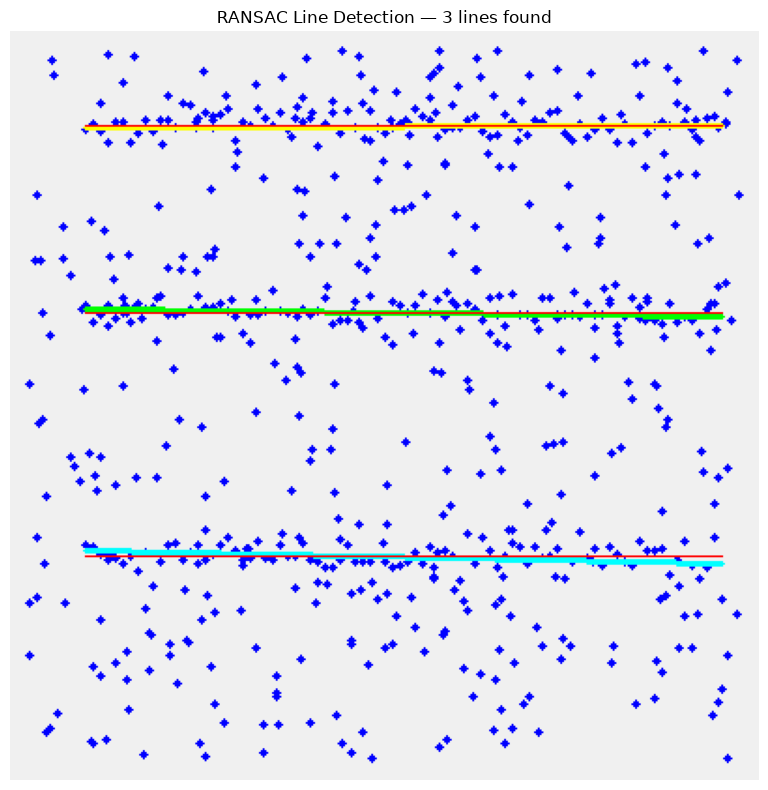

In [6]:
ransac_display = np.zeros((H, W, 3), dtype=np.uint8)
ransac_display[:] = 240

for pt in all_points:
    cv2.circle(ransac_display, (int(pt[0]), int(pt[1])), 2, (0, 0, 255), -1)

colors = [(0, 255, 0), (255, 255, 0), (0, 255, 255)]
for i, (model, _) in enumerate(detected_lines):
    a, b, c = model
    x_vals = np.array([40, 380])
    if abs(b) > 1e-6:
        y_vals = -(a * x_vals + c) / b
        color = colors[i % len(colors)]
        cv2.line(ransac_display, (int(x_vals[0]), int(y_vals[0])),
                  (int(x_vals[1]), int(y_vals[1])), color, 2)

for y in true_line_ys:
    cv2.line(ransac_display, (40, int(y)), (380, int(y)), (255, 0, 0), 1)

plt.figure(figsize=(10, 8))
plt.imshow(ransac_display)
plt.title(f'RANSAC Line Detection — {len(detected_lines)} lines found')
plt.axis('off')
plt.show()

## Comparison: Least-Squares vs RANSAC

The side-by-side comparison below highlights the key difference:
- **Left:** Least-squares tries to fit all points at once, producing a single line that is pulled toward the outlier cloud.
- **Right:** RANSAC iteratively finds lines using only inlier consensus, correctly recovering all three true lines.

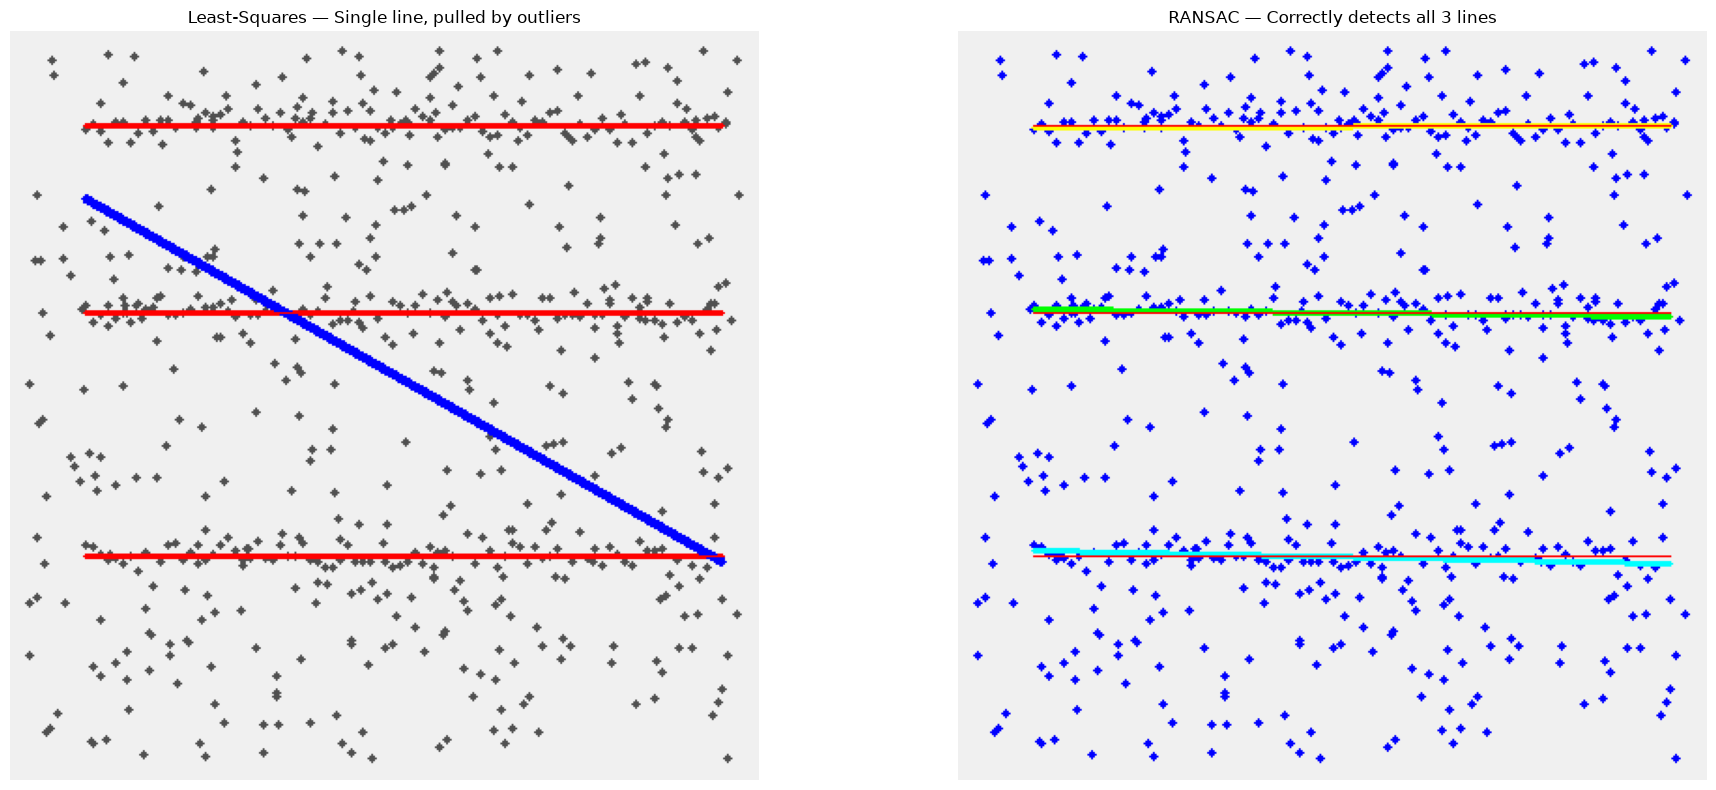

In [7]:
ls_display_full = np.zeros((H, W, 3), dtype=np.uint8)
ls_display_full[:] = 240
for pt in all_points:
    cv2.circle(ls_display_full, (int(pt[0]), int(pt[1])), 2, (80, 80, 80), -1)
if abs(ls_b) > 1e-6:
    y0 = -(ls_a * 40 + ls_c) / ls_b
    y1 = -(ls_a * 380 + ls_c) / ls_b
    cv2.line(ls_display_full, (40, int(y0)), (380, int(y1)), (0, 0, 255), 3)
for y in true_line_ys:
    cv2.line(ls_display_full, (40, int(y)), (380, int(y)), (255, 0, 0), 1)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(ls_display_full)
axes[0].set_title('Least-Squares — Single line, pulled by outliers')
axes[0].axis('off')
axes[1].imshow(ransac_display)
axes[1].set_title('RANSAC — Correctly detects all 3 lines')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Quantitative Analysis

The table below compares the two methods numerically.

In [8]:
total_inlier_points = len(inlier_points)
total_outliers = len(outlier_points)

ransac_inlier_count = sum(len(inliers) for _, inliers in detected_lines)
ransac_outlier_count = len(all_points) - ransac_inlier_count

ls_distances = np.abs(ls_a * all_points[:, 0] + ls_b * all_points[:, 1] + ls_c) / np.sqrt(ls_a**2 + ls_b**2)

print('=' * 55)
print('  Least-Squares vs RANSAC — Quantitative Comparison')
print('=' * 55)
print(f'  Outlier ratio:               {outlier_ratio:.1%}')
print(f'  Total points:                {len(all_points)}')
print('-' * 55)
print(f'  Least-Squares:')
print(f'    Lines detected:            1')
print(f'    Mean distance to line:     {np.mean(ls_distances):.1f} px')
print(f'    Inliers (within 10 px):    {np.sum(ls_distances < 10)}')
print('-' * 55)
print(f'  RANSAC:')
print(f'    Lines detected:            {len(detected_lines)}')
print(f'    Inliers (on detected lines): {ransac_inlier_count}')
print(f'    Outliers (rejected):       {ransac_outlier_count}')
print(f'    Inlier recovery rate:      {ransac_inlier_count / total_inlier_points:.1%}')
print('=' * 55)

  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — Quantitative Comparison
=
  Least-Squares vs RANSAC — 